# Visualizzazione Test

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [49]:
DATA_PATH_1="../data/results_1.csv"
DATA_PATH_2="../data/results_2.csv"
DATA_PATH_3="../data/results_3.csv"
DATA_PATH_4="../data/results_4.csv"
DATA_PATH_5="../data/results_5.csv"
DATA_PATH_6="../data/results_6.csv"
DATA_PATH_7="../data/results_7.csv"

# due variabili diverse per raccogliere il modello corretto dal df e mostrare un titolo adatto
models=['qwen3:1.7b','qwen3:4b-instruct','gemma3:4b','gemma3:1b','granite4:latest', 'phi3:latest', 'granite4:tiny-h']
model_names=['qwen3:1.7b','qwen3:4b-instruct','gemma3:4b','gemma3:1b','granite4:3.8b', 'phi3:3.8b', 'granite4:tiny-h']
num_params=[1.7, 4, 4, 1, 3.8, 3.8, 7]
colors= ['gray', 'blue', 'green', 'yellow', 'pink','brown', 'violet']
mem_sizes=[2.3, 4.1, 5.3, 1.2, 3.2, 4.6, 5.1]

In [50]:
# group all the results in a single df

df1 = pd.read_csv(DATA_PATH_1)
df2 = pd.read_csv(DATA_PATH_2)
df3 = pd.read_csv(DATA_PATH_3)
df4 = pd.read_csv(DATA_PATH_4)
df5 = pd.read_csv(DATA_PATH_5)
df6 = pd.read_csv(DATA_PATH_6)
df7 = pd.read_csv(DATA_PATH_7)

df = pd.concat([df1, df2, df3, df4, df5, df6, df7], sort=False)
df.drop(['Unnamed: 0.1', 'Unnamed: 0'], axis=1, inplace=True)
print(df.shape)
df.head()


(2016, 14)


,model,msg_input,model_response,ore_ordinarie_acc,ore_straordinarie_acc,ore_viaggio_acc,innefficiency_acc,tot_acc,generate_note,total_duration,load_duration,prompt_eval_duration,eval_duration,eval_count
0,qwen3:1.7b,Ieri ho preso un giorno di riposo.,"{""ore_ordinarie"": 0.0, ""ore_straordinarie"": 0....",1,1,1,1,1.0,riposo,1.965496,1.324246,0.267508,0.372823,51
1,qwen3:1.7b,Ieri è stato un vero giorno di pausa: niente i...,"{""ore_ordinarie"":0.0,""ore_straordinarie"":0.0,""...",1,1,1,1,1.0,pausa,0.407078,0.050749,0.012113,0.343156,43
2,qwen3:1.7b,Ieri è stata un’ottima giornata di riposo. Non...,"{""ore_ordinarie"": 0.0, ""ore_straordinarie"": 0....",1,1,1,1,1.0,riposo,0.418546,0.050404,0.006583,0.360835,50
3,qwen3:1.7b,"Ieri ho passato 7 ore al banco di produzione, ...","{""ore_ordinarie"":7.0,""ore_straordinarie"":0.0,""...",1,1,1,1,1.0,vergine,0.375995,0.049107,0.007031,0.319220,43
4,qwen3:1.7b,"Ieri ho passato 6 ore al lavoro, facendo la ma...","{""ore_ordinarie"":6.0,""ore_straordinarie"":0.0,""...",1,1,1,1,1.0,manutenzione delle macchine e controlli degli ...,0.495613,0.047752,0.006668,0.440474,59


In [51]:
# aggiungiamo la colonna originali
CSV_LABEL_FILENAME='../data/labels_tecnico_with_msg.csv'
data = pd.read_csv(CSV_LABEL_FILENAME)
indici_originali = [i % 48 for i in range(df.shape[0])]


df['NOTE_label'] = data.iloc[indici_originali]['NOTE'].values
df['INEFFICIENCY_label'] = data.iloc[indici_originali]['INEFFICIENCY'].values
df.fillna(value={"INEFFICIENCY_label": False}, inplace=True)

print(f"Shape dataset finale: {df.shape}")
print(df[['NOTE_label', 'INEFFICIENCY_label']].head(5))

Shape dataset finale: (2016, 16)
           NOTE_label  INEFFICIENCY_label
0   Giorno di riposo                False
1  Giornata di riposo               False
2  Giornata di riposo               False
3                 NaN               False
4                 NaN               False


C:\Users\nicolo.rossi\AppData\Local\Temp\ipykernel_24716\2775090256.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(value={"INEFFICIENCY_label": False}, inplace=True)


In [52]:
import json
# Funzione per parsare il JSON dalla stringa
def parse_model_response(response_str):
    try:
        # Parsa il JSON dalla stringa
        response_dict = json.loads(response_str)
        return response_dict
    except:
        # In caso di errore, restituisci None per tutti i campi
        return {
            'ore_ordinarie': None,
            'ore_straordinarie': None,
            'ore_viaggio': None,
            'innefficienza': None
        }

# Applica il parsing a tutte le righe
parsed_responses = df['model_response'].apply(parse_model_response)

# aggiungi le colonne
print(df.shape)
df['predict_ore_ordinarie'] = parsed_responses.apply(lambda x: x.get('ore_ordinarie'))
df['predict_ore_straordinarie'] = parsed_responses.apply(lambda x: x.get('ore_straordinarie'))
df['predict_ore_viaggio'] = parsed_responses.apply(lambda x: x.get('ore_viaggio'))
df['predict_innefficienza'] = parsed_responses.apply(lambda x: x.get('innefficienza'))
print(df.shape)

(2016, 16)
(2016, 20)


In [53]:
import random
df['msg_input'].iloc[:10]
def display_msg(messages, nums):
    for _ in range(nums):
        idx = random.randint(0, len(messages)-1)
        print(f' messaggio numero {idx}: {messages.iloc[idx]}\n')

display_msg(df['msg_input'], 5)

 messaggio numero 1173: Ieri ho fatto 7,5 ore di lavoro normale e mezz'ora  di spostamento. Non ci sono state straordinari. Ho passato un po’ di tempo a sistemare la linea di montaggio del prodotto X, ma al fine del turno tutto è andato a buon fine.

 messaggio numero 1895: Ieri ho speso 8 ore di lavoro normale, intervenendo sui due pressi di linea 3 per rimettere in ordine le valvole di sguaina. Ho aggiunto un po’ di lubrificante extra e controllato le tenute in rame. Per finire, ho dovuto fare un’ultima verifica sul circuito di alimentazione, che mi ha richiesto mezza ora in straordinario, così da coprire un piccolo ritardo del macchinista.  
Mi è capitato un’improvvisa inefficienza: il sensore di pressione non rispondeva più e l’intero sistema di sicurezza ha attivato l’allarme. Dopo aver eseguito la diagnostica, ho rimosso il modulo danneggiato, reinstallato il firmware e riavviato il sistema; l’interruzione è andata risolta.  
Non ci sono state ore di viaggio, né altre note da agg

In [54]:
display_msg(df.loc[df['INEFFICIENCY_label'] == True]['msg_input'], 5)

 messaggio numero 175: Ieri mi sono girato per tutto il turno, mettendo in campo 7 ore di lavoro regolare. Il viaggio verso il cliente è durato circa un’ora, così ho speso 1h sul percorso. Non ho fatto ore extra, quindi tutto sotto la soglia prevista. Ci sono state qualche inefficienza: la macchina 3B ha subito un blocco improvviso durante il controllo, così mi è servito un tempo in più per sistemarla e per aggiornare il log. Non ci sono state note aggiuntive da registrare.

 messaggio numero 208: Ieri ho fatto 7 ore di lavoro standard, un’ora di straordinario e ho impiegato un’ora di viaggio. Ci è stato un piccolo contrattempo: la pressa non ha girato al 100 %, quindi la produzione è rimasta leggermente in ritardo.

 messaggio numero 64: Ieri ho speso 8 ore di lavoro normale, più 1 ora di straordinario quando mi hanno chiesto di completare un pezzo di prova prima della chiusura. Non ho speso tempo di viaggio, tutto era sul posto. C'è stato un piccolo contrattempo: la macchina di tagli

In [ ]:
# add the result of granite4:tiny-h
GRANITE_tiny_PATH_0= "../data/results_granite_1.csv"
GRANITE_tiny_PATH_1= "../data/results_granite_2.csv"
GRANITE_tiny_PATH_2= "../data/results_granite_3.csv"
GRANITE_tiny_PATH_3= "../data/results_granite_4.csv"
GRANITE_tiny_PATH_4= "../data/results_granite_5.csv"
GRANITE_tiny_PATH_5= "../data/results_granite_6.csv"
GRANITE_tiny_PATH_6= "../data/results_granite_7.csv"


df1 = pd.read_csv(GRANITE_tiny_PATH_0)
df2 = pd.read_csv(GRANITE_tiny_PATH_1)
df3 = pd.read_csv(GRANITE_tiny_PATH_2)
df4 = pd.read_csv(GRANITE_tiny_PATH_3)
df5 = pd.read_csv(GRANITE_tiny_PATH_4)
df6 = pd.read_csv(GRANITE_tiny_PATH_5)
df7 = pd.read_csv(GRANITE_tiny_PATH_6)

df_tiny_h = pd.concat([df1, df2, df3, df4, df5, df6, df7], sort=False)

In [59]:
# add df
df = pd.concat([df, df_tiny_h])

# Test granit4:latest vs tiny-h

In [35]:
# add the result of granite4:tiny-h
GRANITE_tiny_PATH_0= "../data/results_granite_old_1.csv"
GRANITE_tiny_PATH_1= "../data/results_granite_old_2.csv"
GRANITE_tiny_PATH_2= "../data/results_granite_old_3.csv"
GRANITE_tiny_PATH_3= "../data/results_granite_old_4.csv"
GRANITE_tiny_PATH_4= "../data/results_granite_old_5.csv"
GRANITE_tiny_PATH_5= "../data/results_granite_old_6.csv"
GRANITE_tiny_PATH_6= "../data/results_granite_old_7.csv"


df1 = pd.read_csv(GRANITE_tiny_PATH_0)
df2 = pd.read_csv(GRANITE_tiny_PATH_1)
df3 = pd.read_csv(GRANITE_tiny_PATH_2)
df4 = pd.read_csv(GRANITE_tiny_PATH_3)
df5 = pd.read_csv(GRANITE_tiny_PATH_4)
df6 = pd.read_csv(GRANITE_tiny_PATH_5)
df7 = pd.read_csv(GRANITE_tiny_PATH_6)

df_latest = pd.concat([df1, df2, df3, df4, df5, df6, df7], sort=False)

In [ ]:
# add df
df = pd.concat([df_latest, df_tiny_h])

In [39]:
models = ['granite4:latest', 'granite4:tiny-h']

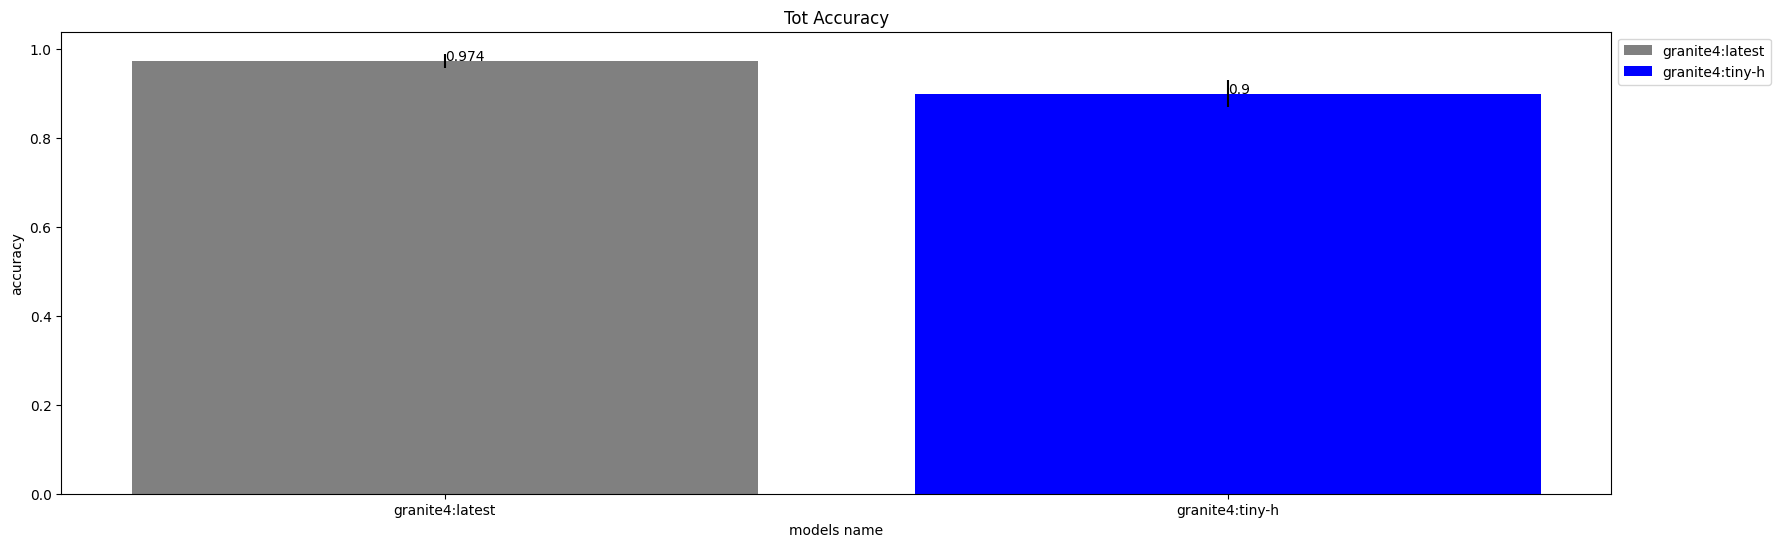

In [40]:
def add_labels(labels, vals):
    for i in range(len(labels)):
        plt.text(i,vals[i], vals[i])

media_group = []
CI_group = []
for model in models:
    acc_media = round(df.loc[df['model'] == model]['tot_acc'].mean(),3)
    n = len(df)
    # intervallo di confidenza al 99 %
    CI = 2.576 * np.sqrt(acc_media * (1- acc_media) / n)
    media_group.append(acc_media)
    CI_group.append(CI)

plt.figure(figsize=(20,6))
plt.bar(models, media_group, yerr=CI_group, color=colors, label=models)
add_labels(models,media_group)
plt.title("Tot Accuracy")
plt.xlabel("models name")
plt.ylabel("accuracy")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))

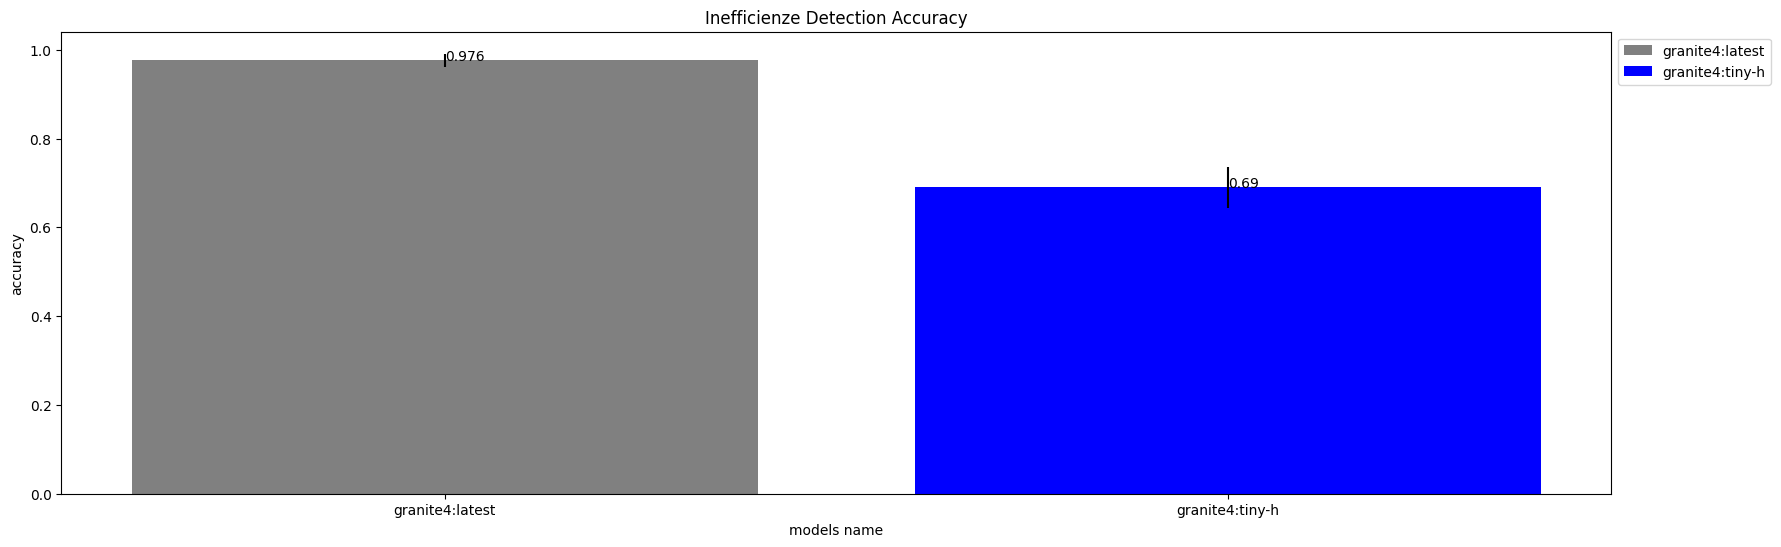

In [42]:
# Efficienze accuracy
def add_labels(labels, vals):
    for i in range(len(labels)):
        plt.text(i,vals[i], vals[i])

media_group = []
CI_group = []
for model in models:
    acc_media = round(df.loc[df['model'] == model]['innefficiency_acc'].mean(),3)
    n = len(df)
    # intervallo di confidenza al 99 %
    CI = 2.576 * np.sqrt(acc_media * (1- acc_media) / n)
    media_group.append(acc_media)
    CI_group.append(CI)

plt.figure(figsize=(20,6))
plt.bar(models, media_group, yerr=CI_group, color=colors, label=models)
add_labels(models,media_group)
plt.title("Inefficienze Detection Accuracy")
plt.xlabel("models name")
plt.ylabel("accuracy")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))

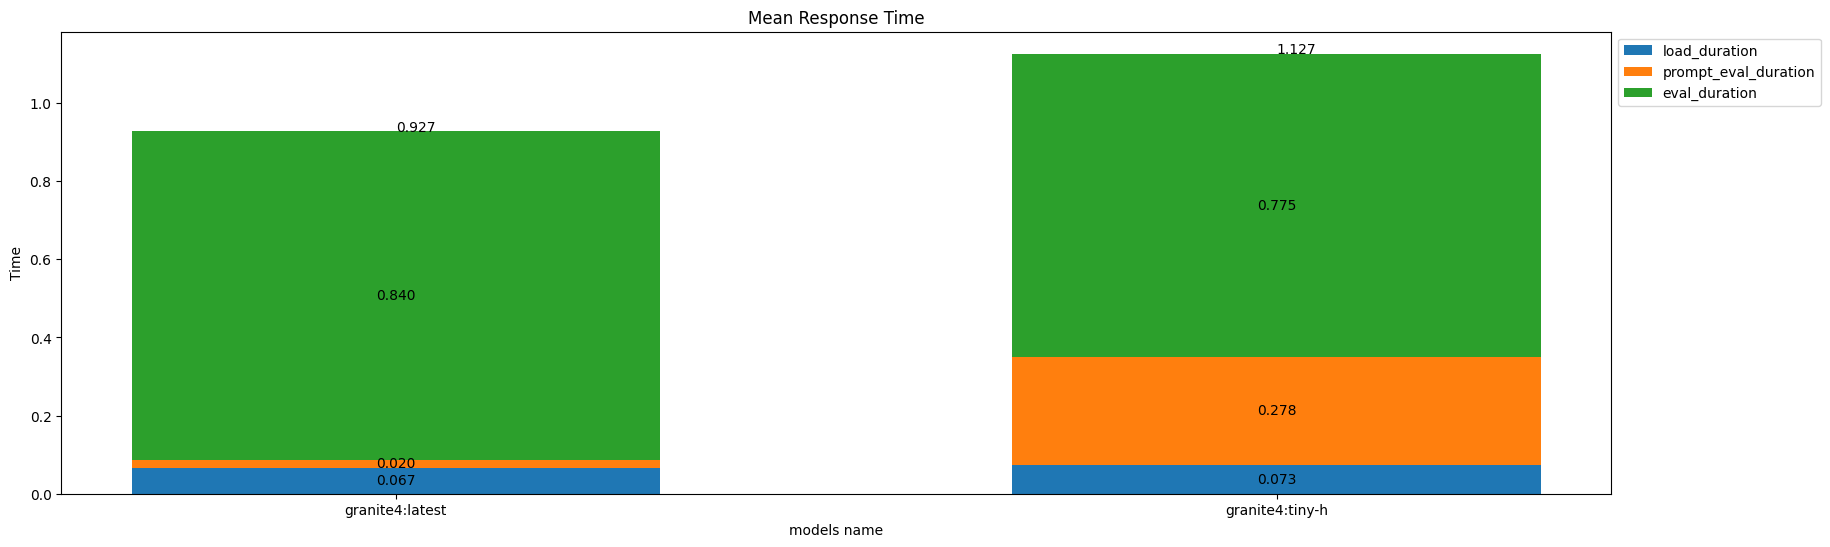

In [48]:
# response time medio 
def add_labels(labels, vals):
    for i in range(len(labels)):
        plt.text(i,vals[i], vals[i])

medie = {
    'load_duration': [],
    'prompt_eval_duration': [],
    'eval_duration': []
}
media_tot_group = []
media_load_group = []
media_prompt_group = []
media_eval_group = []

for model in models:
    acc_media = round(df.loc[df['model'] == model]['total_duration'].mean(), 3)
    acc_load_media = round(df.loc[df['model'] == model]['load_duration'].mean(), 3)
    acc_prompt_media = round(df.loc[df['model'] == model]['prompt_eval_duration'].mean(), 3)
    acc_eval_media = round(df.loc[df['model'] == model]['eval_duration'].mean(), 3)
    
    media_tot_group.append(acc_media)
    medie['load_duration'].append(acc_load_media)
    medie['prompt_eval_duration'].append(acc_prompt_media)
    medie['eval_duration'].append(acc_eval_media)
    

plt.figure(figsize=(20,6))
bottom = np.zeros(len(models))
for tipo, media in medie.items():
    media_array = np.array(media)
    p = plt.bar(models, media_array, width=0.6, label=tipo, bottom=bottom)
    bottom += media_array
    plt.bar_label(p, label_type='center', fmt="%.3f")

add_labels(models,media_tot_group)
plt.title("Mean Response Time")
plt.xlabel("models name")
plt.ylabel("Time")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))

# Display Tot Accuracy

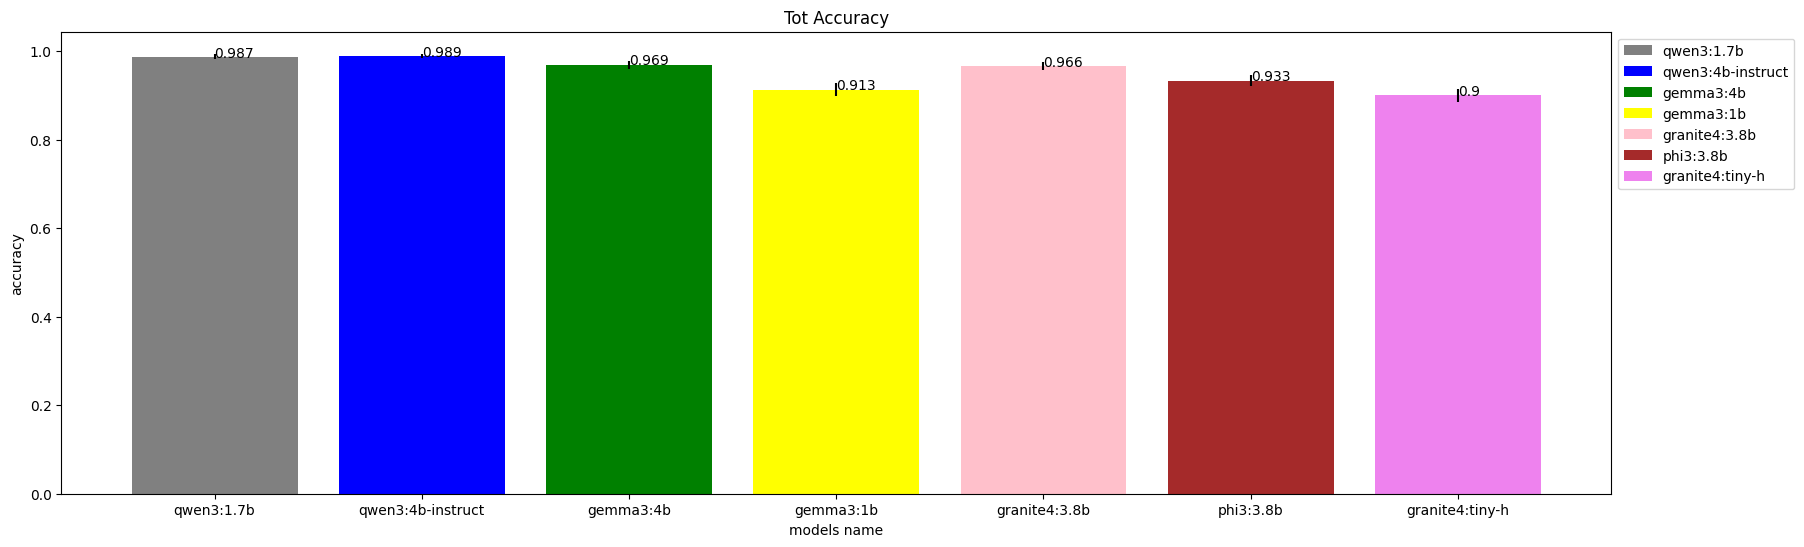

In [67]:
def add_labels(labels, vals):
    for i in range(len(labels)):
        plt.text(i,vals[i], vals[i])

media_group = []
CI_group = []
for model in models:
    acc_media = round(df.loc[df['model'] == model]['tot_acc'].mean(),3)
    n = len(df)
    # intervallo di confidenza al 99 %
    CI = 2.576 * np.sqrt(acc_media * (1- acc_media) / n)
    media_group.append(acc_media)
    CI_group.append(CI)

plt.figure(figsize=(20,6))
plt.bar(model_names, media_group, yerr=CI_group, color=colors, label=model_names)
add_labels(models,media_group)
plt.title("Tot Accuracy")
plt.xlabel("models name")
plt.ylabel("accuracy")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))

# Display Accuracy per tipologie di Ore

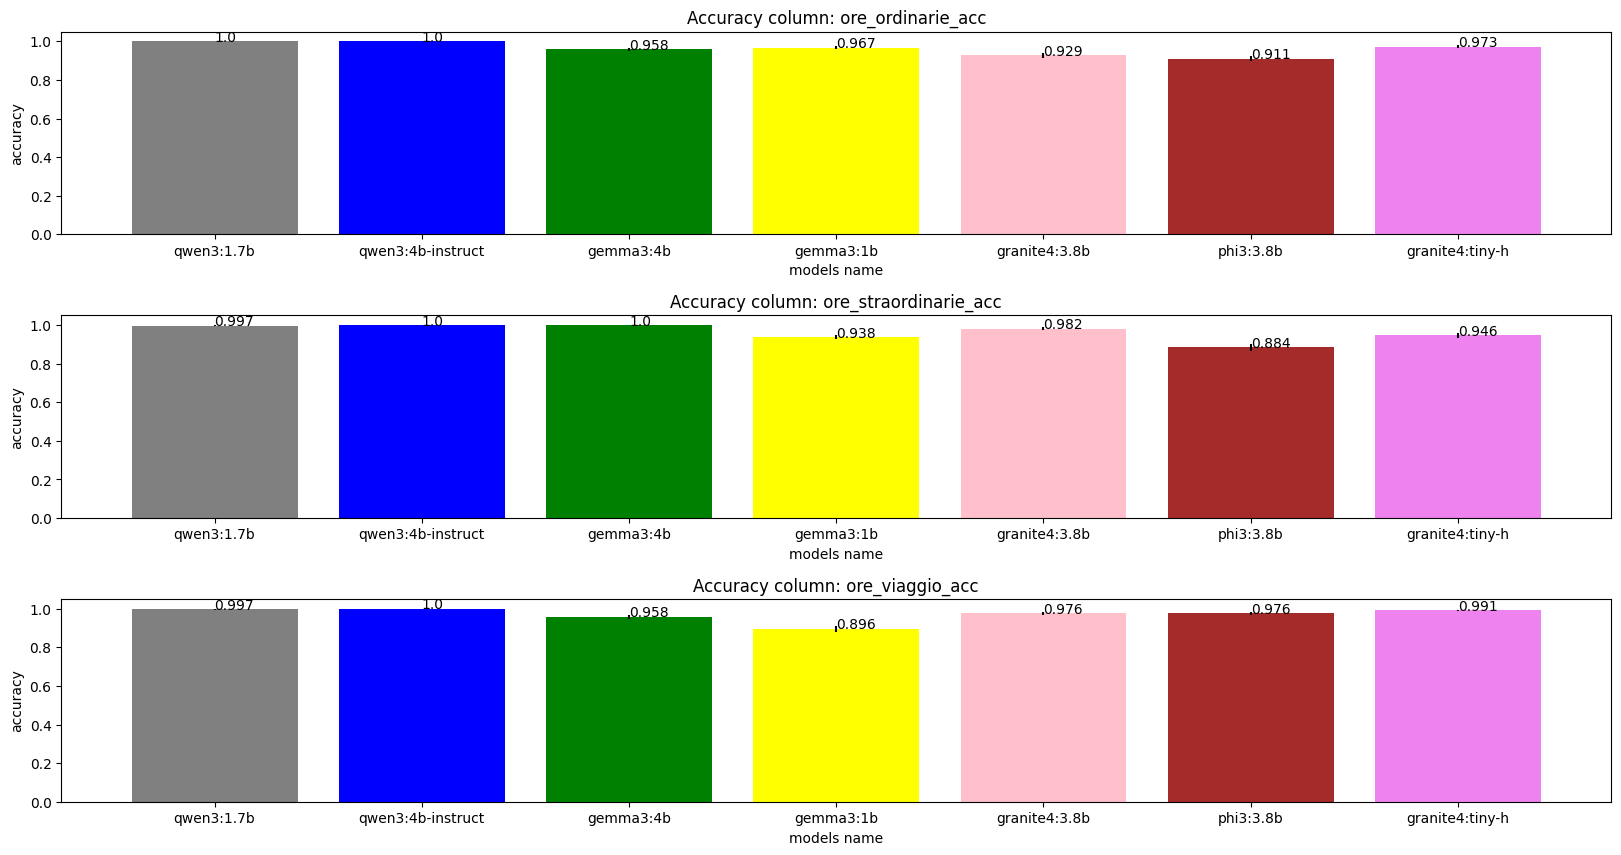

In [61]:
def add_labels_w_axis(ax, labels, vals, offset=0.02):
    for i in range(len(labels)):
        ax.text(i, vals[i], vals[i])

# accuracy per tipo d'orario
def display_ore(cat, z=2.576):
    """
    Display delle ore accuracy
    """
    
    fig, axis = plt.subplots(3)
    fig.set_figheight(10)
    fig.set_figwidth(20)
    for idx,column in enumerate(cat):
        media_group = []
        CI_group = []
        for model in models:
            acc_media = round(df.loc[df['model'] == model][column].mean(),3)
            n = len(df)
            # intervallo di confidenza
            CI = z * np.sqrt(acc_media * (1- acc_media) / n)
            media_group.append(acc_media)
            CI_group.append(CI)
        axis[idx].bar(model_names, media_group, yerr=CI_group, color=colors, label=model_names)
        add_labels_w_axis(axis[idx], models, media_group)
        axis[idx].set_title(f'Accuracy column: {column}')
        axis[idx].set_xlabel('models name')
        axis[idx].set_ylabel('accuracy')
        

columns = ['ore_ordinarie_acc', 'ore_straordinarie_acc', 'ore_viaggio_acc']
display_ore(columns)
plt.subplots_adjust(hspace=0.4)
plt.show()

# Accuracy Detection Inefficienze

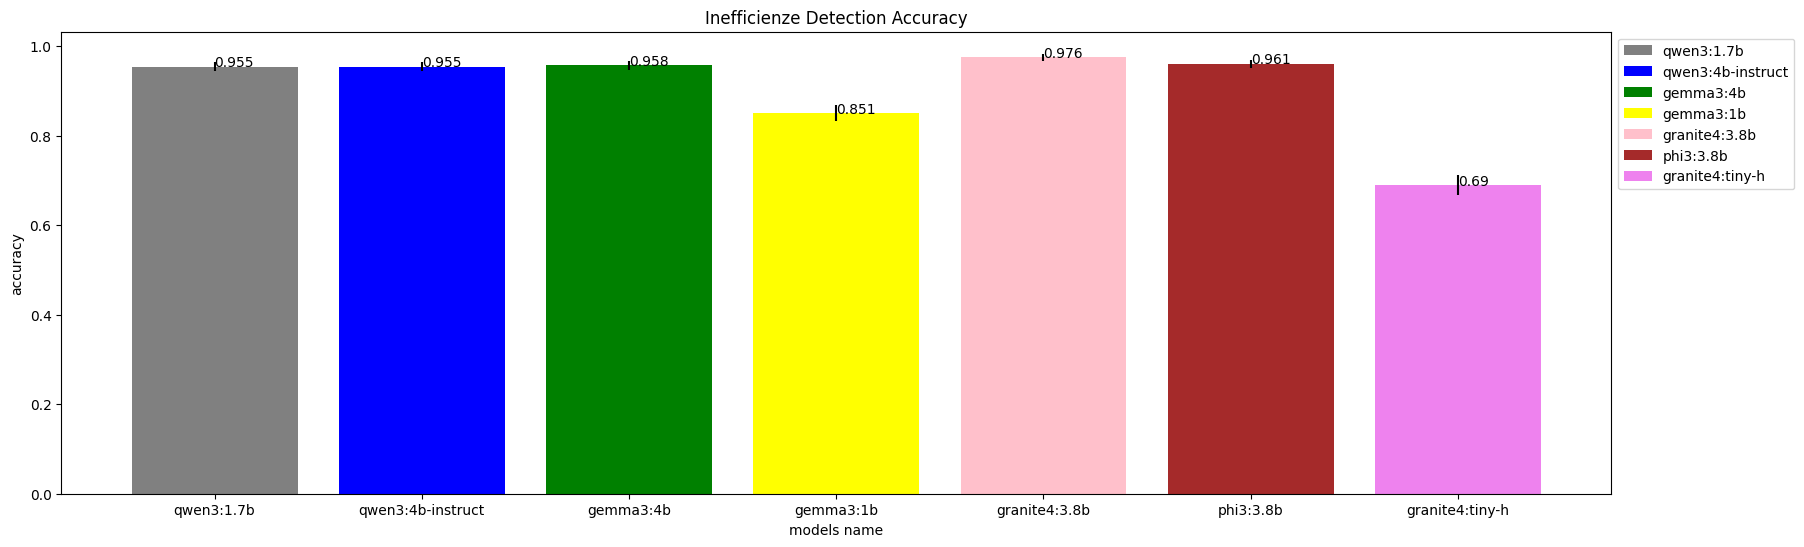

In [66]:
# Efficienze accuracy
def add_labels(labels, vals):
    for i in range(len(labels)):
        plt.text(i,vals[i], vals[i])

media_group = []
CI_group = []
for model in models:
    acc_media = round(df.loc[df['model'] == model]['innefficiency_acc'].mean(),3)
    n = len(df)
    # intervallo di confidenza al 99 %
    CI = 2.576 * np.sqrt(acc_media * (1- acc_media) / n)
    media_group.append(acc_media)
    CI_group.append(CI)

plt.figure(figsize=(20,6))
plt.bar(model_names, media_group, yerr=CI_group, color=colors, label=model_names)
add_labels(models,media_group)
plt.title("Inefficienze Detection Accuracy")
plt.xlabel("models name")
plt.ylabel("accuracy")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))

# Mean Response Time

## With out labels 

C:\Users\nicolo.rossi\AppData\Local\Temp\ipykernel_24716\722422371.py:14: RuntimeWarning: invalid value encountered in sqrt
  CI = 2.576 * np.sqrt(acc_media * (1- acc_media) / n)


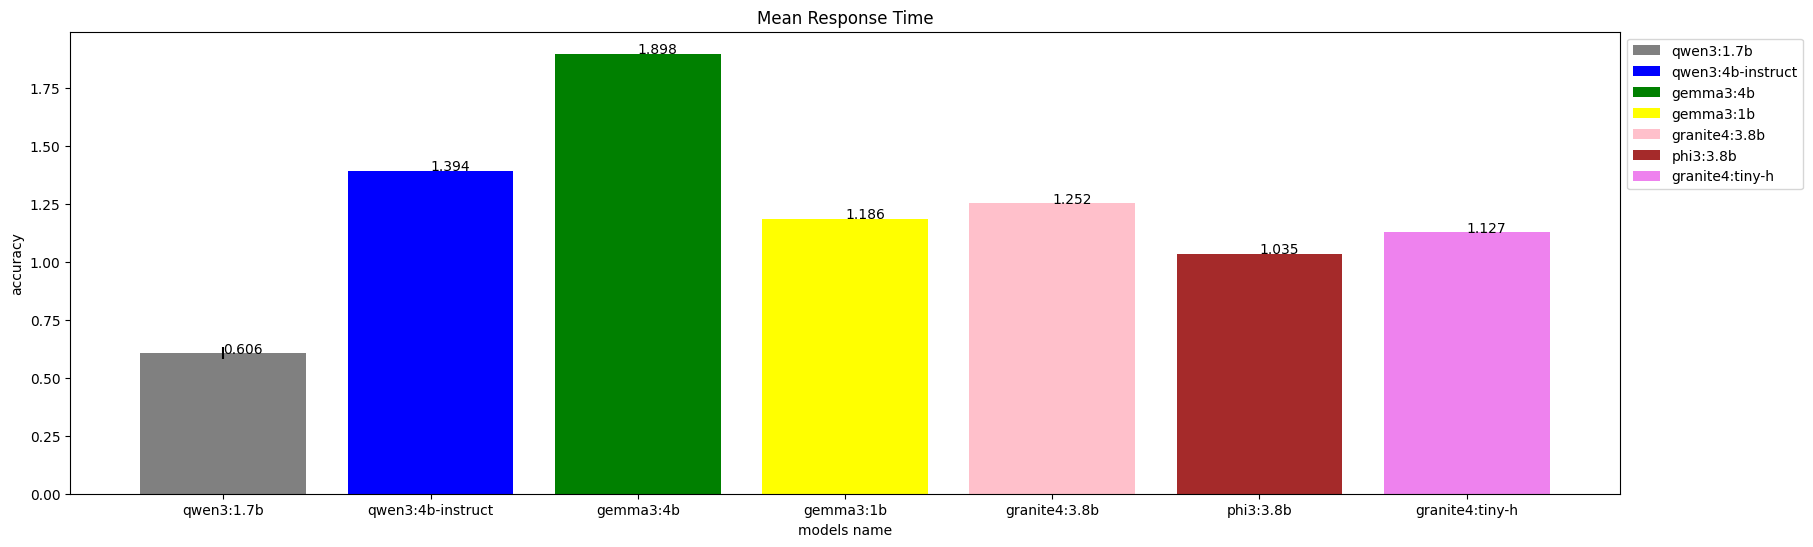

In [33]:
# response time medio

def add_labels(labels, vals):
    for i in range(len(labels)):
        plt.text(i,vals[i], vals[i])

media_group = []
CI_group = []

for model in models:
    acc_media = round(df.loc[df['model'] == model]['total_duration'].mean(), 3)
    n = len(df)
    # intervallo di confidenza al 99 %
    CI = 2.576 * np.sqrt(acc_media * (1- acc_media) / n)
    media_group.append(acc_media)
    CI_group.append(CI)

plt.figure(figsize=(20,6))
plt.bar(model_names, media_group, yerr=CI_group, color=colors, label=model_names)
add_labels(models,media_group)
plt.title("Mean Response Time")
plt.xlabel("models name")
plt.ylabel("accuracy")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))

## with label

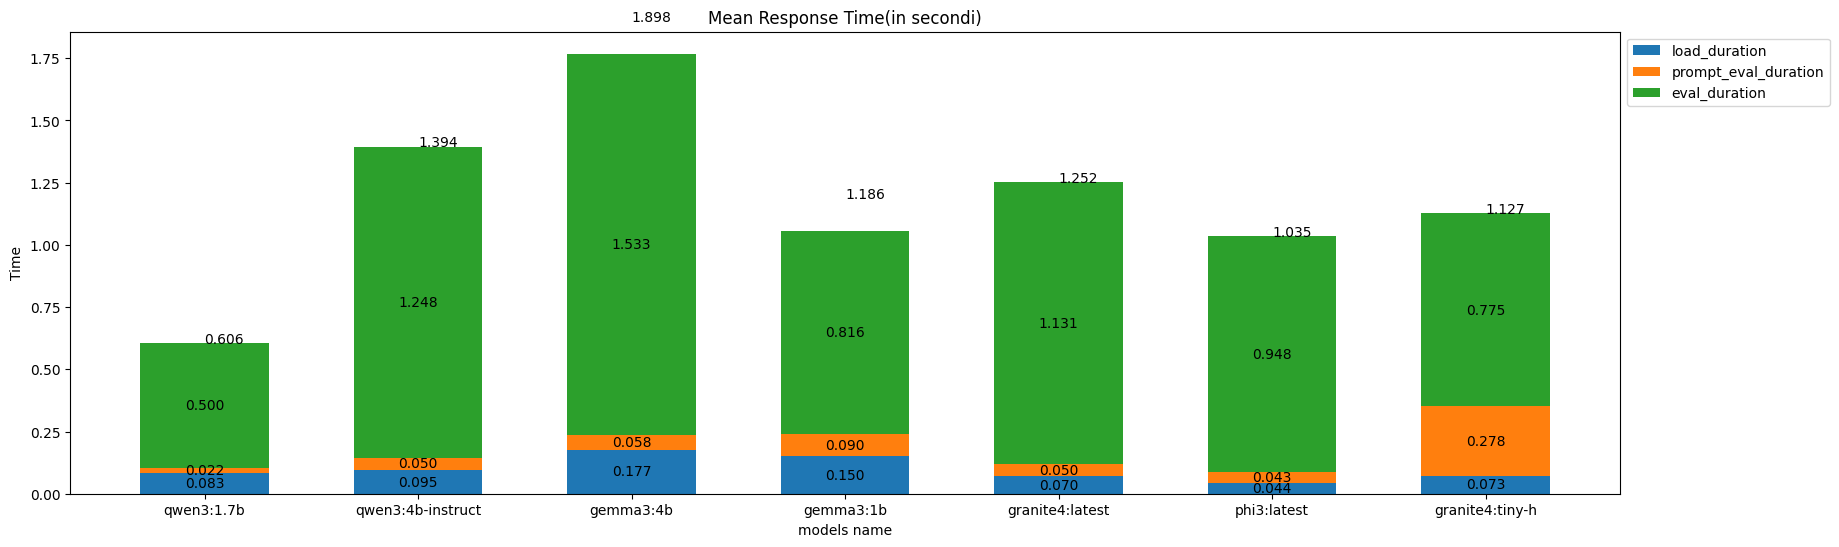

In [65]:
# response time medio 
def add_labels(labels, vals):
    for i in range(len(labels)):
        plt.text(i,vals[i], vals[i])

medie = {
    'load_duration': [],
    'prompt_eval_duration': [],
    'eval_duration': []
}
media_tot_group = []
media_load_group = []
media_prompt_group = []
media_eval_group = []

for model in models:
    acc_media = round(df.loc[df['model'] == model]['total_duration'].mean(), 3)
    acc_load_media = round(df.loc[df['model'] == model]['load_duration'].mean(), 3)
    acc_prompt_media = round(df.loc[df['model'] == model]['prompt_eval_duration'].mean(), 3)
    acc_eval_media = round(df.loc[df['model'] == model]['eval_duration'].mean(), 3)
    
    media_tot_group.append(acc_media)
    medie['load_duration'].append(acc_load_media)
    medie['prompt_eval_duration'].append(acc_prompt_media)
    medie['eval_duration'].append(acc_eval_media)
    

plt.figure(figsize=(20,6))
bottom = np.zeros(len(models))
for tipo, media in medie.items():
    media_array = np.array(media)
    p = plt.bar(models, media_array, width=0.6, label=tipo, bottom=bottom)
    bottom += media_array
    plt.bar_label(p, label_type='center', fmt="%.3f")

add_labels(models,media_tot_group)
plt.title("Mean Response Time(in secondi)")
plt.xlabel("models name")
plt.ylabel("Time")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))

# Memory Footprint dei modelli 

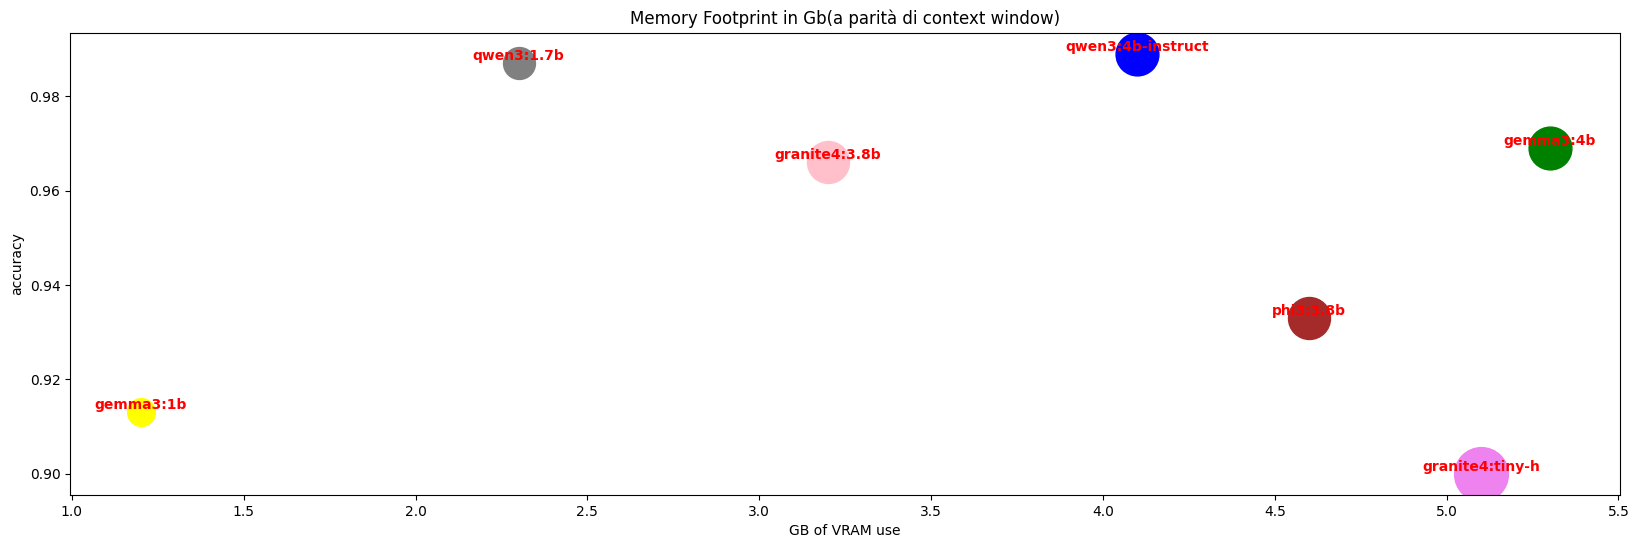

In [30]:
# memory footprint
def add_labels(x_coords, y_coords, labels, offset=0.0):
    for i in range(len(labels)):
        plt.text(x_coords[i], y_coords[i] + offset, labels[i], 
                 ha='center', va='bottom', weight='bold', c='red')

media_group = []
var_group = []
for model in models:
    acc_media = round(df.loc[df['model'] == model]['tot_acc'].mean(),3)
    media_group.append(acc_media)

plt.figure(figsize=(20,6))
sizes = np.array(num_params)
sizes_norm = np.interp(sizes, (sizes.min(), sizes.max()), (400, 1500))

for i in range(len(mem_sizes)):
    plt.scatter(mem_sizes[i], media_group[i], s=sizes_norm[i], 
                color=colors[i], label=model_names[i])

add_labels(mem_sizes, media_group, model_names)
plt.title("Memory Footprint in Gb(a parità di context window)")
plt.xlabel("GB of VRAM use")
plt.ylabel("accuracy")
plt.locator_params(axis='x', nbins=10)

# Confusion matrix innefficienze 

In [29]:
# confusion matrix delle innefficienze
def confusion_matrices_per_model(df, model_name):
    """
    Crea 5 Confusion Matrix  per un modello specifico, una per ogni test.
    """
    # Filtra il dataset per il modello specifico
    df_model = df[df['model'] == model_name].reset_index(drop=True)
    
    print(f"\n{'='*60}")
    print(f"CONFUSION MATRICES - Modello: {model_name}")
    print(f"{'='*60}\n")
    
    # Per ogni test (5 test da 48 righe ciascuno)
    for test_idx in range(5):
        start_idx = test_idx * 48
        end_idx = start_idx + 48
        
        # Estrai i dati per questo test
        df_test = df_model.iloc[start_idx:end_idx]
        
        # Crea la confusion matrix con crosstab
        cm = pd.crosstab(df_test['INEFFICIENCY_label'], df_test['predict_innefficienza'], 
                         rownames=['Vero'], colnames=['Predetto'], 
                         margins=True, margins_name='Totale')
        
        # Calcola accuracy
        accuracy = (cm.loc[False, False] + cm.loc[True, True]) / cm.loc['Totale', 'Totale']
        
        print(f"Test {test_idx + 1} - Accuracy: {accuracy:.2%}")
        print(cm)
        print()

In [30]:
for model in models:
    confusion_matrices_per_model(df, model)


CONFUSION MATRICES - Modello: qwen3:1.7b

Test 1 - Accuracy: 95.83%
Predetto  False  True  Totale
Vero                         
False        38     0      38
True          2     8      10
Totale       40     8      48

Test 2 - Accuracy: 95.83%
Predetto  False  True  Totale
Vero                         
False        38     0      38
True          2     8      10
Totale       40     8      48

Test 3 - Accuracy: 93.75%
Predetto  False  True  Totale
Vero                         
False        38     0      38
True          3     7      10
Totale       41     7      48

Test 4 - Accuracy: 95.83%
Predetto  False  True  Totale
Vero                         
False        38     0      38
True          2     8      10
Totale       40     8      48

Test 5 - Accuracy: 95.83%
Predetto  False  True  Totale
Vero                         
False        38     0      38
True          2     8      10
Totale       40     8      48


CONFUSION MATRICES - Modello: qwen3:4b-instruct

Test 1 - Accuracy: 95.

# Accuracy Note

C:\Users\nicolo.rossi\AppData\Local\Temp\ipykernel_3832\2371750390.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  true.fillna(value="null", inplace=True)


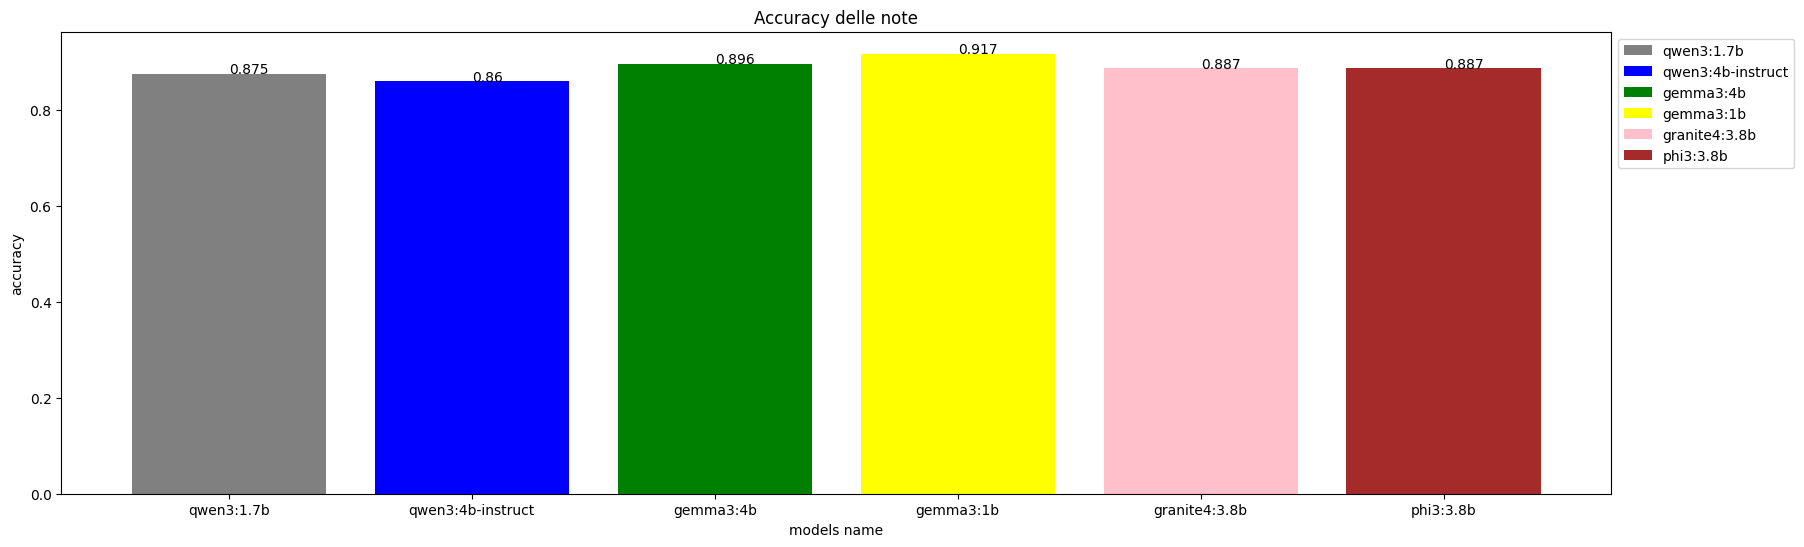

In [31]:
# controlliamo se la predict label note contiene label note
def add_labels(labels, vals):
    for i in range(len(labels)):
        plt.text(i,vals[i], vals[i])

media_group = []
for model in models:
    predict = df.loc[df['model'] == model]['generate_note']
    true = df.loc[df['model'] == model]['NOTE_label']
    # facciamo il fillna con null
    true.fillna(value="null", inplace=True)
    # check
    values = []
    for idx in range(predict.shape[0]):
        values.append( 0  if str(true.iloc[idx]).strip().lower() in str(predict.iloc[idx]).strip().lower() else 1)
    
    acc_media = round(sum(values)/len(values), 3)
    media_group.append(acc_media)


plt.figure(figsize=(20,6))
plt.bar(model_names, media_group, color=colors, label=model_names)
add_labels(models,media_group)
plt.title("Accuracy delle note")
plt.xlabel("models name")
plt.ylabel("accuracy")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))